# 👨🏻‍💻 **CRISPr L3 Workshop Exercise**

## 🛠️ **Setup**

1) File >> Open notebook >> Github
2) Copy and past `https://github.com/govtech-data-practice/CRISPrWorkshop.git` to git clone




In [2]:
!rm -rf /content/CRISPrWorkshop

In [3]:
!git clone https://github.com/zendenleong/CRISPrWorkshop.git

Cloning into 'CRISPrWorkshop'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 2.71 MiB | 3.95 MiB/s, done.
Resolving deltas: 100% (3/3), done.


#### **Ensure that you have the following data sets:**
  1) hdb_resale_data_contract.yaml
  2) hdb_resale_golden.csv
  3) hdb_resale_with_errors.csv

In [4]:
ls CRISPrWorkshop/

CRISPr_notebook.ipynb          hdb_resale_golden.csv       README.md
hdb_resale_data_contract.yaml  hdb_resale_with_errors.csv


##  🦉 **Section 1: Demo of vowl-lens and vowl-canvas**

**vowl-lens** is a data validation application where you can upload, validate and evaluate data quality with the help of a data contract.

In this demo, we will be using _**hdb_resale_data_contract.yaml**_ to validate
 _**hdb_resale_with_errors.csv**_ on vowl-lens, getting a comprehensive overview of data validation results and data quality dimensions.


**vowl-lens**

- COMET users: [vowl-lens-comet](https://vowl-ui.gvt-build26-data-practice.stg.paas.sandbox.gov.sg)



- SEED users: [vowl-lens-seed](https://p01--data-contract-validator-ui--ywq8js2yw5xf.skmm8r--govpaas.code.run)









_**Now that you have seen the data quality dashboard, you might be wondering how do we generate this data contract?**_

We can generate a data contract on vowl-canvas with a golden dataset. A golden dataset is a prime example of validated, high-quality data that represents the expected data quality and structure.

**vowl-canvas** will learn from the values to infer precise validation rules, data patterns and constraints for optimal contract generation. We will be using ***hdb_resale_golden.csv***.



**vowl-canvas**

- COMET users: [vowl-canvas-comet](https://vowl-canvas.gvt-build26-data-practice.stg.paas.sandbox.gov.sg)
- SEED users:  [vowl-canvas-seed](p01--data-contracts-canvas-ui--6zkqqjv624ps.skmm8r--govpaas.code.run)





## 📊 **Section 2: Validation of HDB Resale data using vowl library**

In this section, you will try out the data validation process via the vowl library in code instead of an UI.

In [5]:
!pip install vowl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.2/182.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.0/719.0 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 43.2 MB/s eta 0:00:00
  Attempting uninstall: sqlglot
    Found existing installation: sqlglot 25.20.2
    Uninstalling sqlglot-25.20.2:
      Successfully uninstalled sqlglot-25.20.2
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: ibis-framework
    Found existing installation: ibis-framework 9.5.0
    Uninstalling ibis-framew

In [32]:
import pandas as pd
from io import StringIO
from vowl import validate_data
import warnings
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### 🔎 **Validating HDB Resale data with vowl library**

In [33]:
df = pd.read_csv("/content/CRISPrWorkshop/hdb_resale_with_errors.csv")

In [34]:
result = validate_data("/content/CRISPrWorkshop/hdb_resale_data_contract.yaml", df=df)

In [35]:
result.display_full_report()



=== Data Quality Validation Results ===
   Contract Version:      v3.1.0
   Contract ID:           c11443ee-542f-4442-b28d-2d224342be37
   Schemas:               hdb_resale_prices

 OVERALL DATA QUALITY
   Overall:
     Checks Pass Rate:       41 / 54 (75.9%)

   hdb_resale_prices:
     Overall:
       Checks Pass Rate:       41 / 54 (75.9%)
       ERRORED Checks:         0
     Single Table:
       Checks Pass Rate:       41 / 54 (75.9%)
       ERRORED Checks:         0
       Unique Passed Rows:     201,558 / 201,879 (99.8%)
     Multi Table:
       Checks Pass Rate:       0 / 0 (N/A)
       ERRORED Checks:         0
       Non-unique Failed Rows: 0


 CHECK RESULTS
+----------------------------------------------------+---------------------------------------+-------------------+--------+-------------------+----------+--------+----------------+
| check_id                                           | Target                                | tables_in_query   | status | operator        

ValidationResult(passed=False, checks=54, passed_checks=41, failed_checks=13)

### 📋 **Data Quality Reporting**

In [10]:
# Only run this code block if you want to see the entire json of the validation summary (It can get quite large if there are many DQ rules)

# import json
# print(json.dumps(result.summary, indent=2, default=str))

In [11]:
def print_quality_dimensions_summary(result):
    check_results = result.summary['check_results']
    total_rows = list(result.summary['validation_summary']['total_rows_by_schema'].values())[0]

    dimensions = {}
    for check in check_results:
        dimension = check['check_definition'].get('dimension', 'uncategorized')
        if dimension not in dimensions:
            dimensions[dimension] = {'total': 0, 'passed': 0, 'failed_records': 0}
        dimensions[dimension]['total'] += 1
        if check['status'] == 'PASSED':
            dimensions[dimension]['passed'] += 1
        dimensions[dimension]['failed_records'] += check['failed_rows_count']

    metrics = {}
    print("=" * 60)
    print("Data Quality Dimensions Breakdown")
    print("=" * 60)
    for dimension, stats in sorted(dimensions.items()):
        rule_level = (stats['passed'] / stats['total'] * 100) if stats['total'] > 0 else 0
        row_level = ((total_rows - stats['failed_records']) / total_rows * 100) if total_rows > 0 else 0

        metrics[dimension] = {
            'rule_level': rule_level,
            'row_level': row_level,
            'rules_passed': stats['passed'],
            'rules_total': stats['total'],
            'failed_records': stats['failed_records'],
            'total_rows': total_rows,
        }

        print(f"\n{dimension.upper()}")
        print(f"  Rules Passed: {stats['passed']}/{stats['total']} ({rule_level:.4f}%)")
        print(f"  Failed Records: {stats['failed_records']}/{total_rows} ({stats['failed_records']/total_rows*100:.4f}%)")
        print(f"  Rule Level {dimension.capitalize()}: {rule_level:.4f}%")
        print(f"  Row Level {dimension.capitalize()}: {row_level:.4f}%")
    print("\n" + "=" * 60)

    return metrics

In [12]:
metrics = print_quality_dimensions_summary(result)

Data Quality Dimensions Breakdown

ACCURACY
  Rules Passed: 0/1 (0.0000%)
  Failed Records: 1/201879 (0.0005%)
  Rule Level Accuracy: 0.0000%
  Row Level Accuracy: 99.9995%

COMPLETENESS
  Rules Passed: 12/15 (80.0000%)
  Failed Records: 4/201879 (0.0020%)
  Rule Level Completeness: 80.0000%
  Row Level Completeness: 99.9980%

CONFORMITY
  Rules Passed: 29/37 (78.3784%)
  Failed Records: 28/201879 (0.0139%)
  Rule Level Conformity: 78.3784%
  Row Level Conformity: 99.9861%

UNIQUENESS
  Rules Passed: 0/1 (0.0000%)
  Failed Records: 596/201879 (0.2952%)
  Rule Level Uniqueness: 0.0000%
  Row Level Uniqueness: 99.7048%



#### **Agency Data Quality Monitoring**

- Data quality can be measured across multiple dimensions — accuracy, completeness, conformity, and uniqueness. For each dimension, we can report both rule-level and row-level metrics.



- Rule-level measures the proportion of validation rules that passed, while row-level measures the proportion of records free from issues.

- Different agencies have different requirements: some monitor at the rule level, others at the row level. Both perspectives are provided here to support varied use cases. With vowl and data contracts, this monitoring process is standardised and simplified.


- ***Do note that for Data Provisioning Standards (DPS), uniqueness is not one of the metrics to be reported, however, you can still track this for your own agency data quality monitoring.***


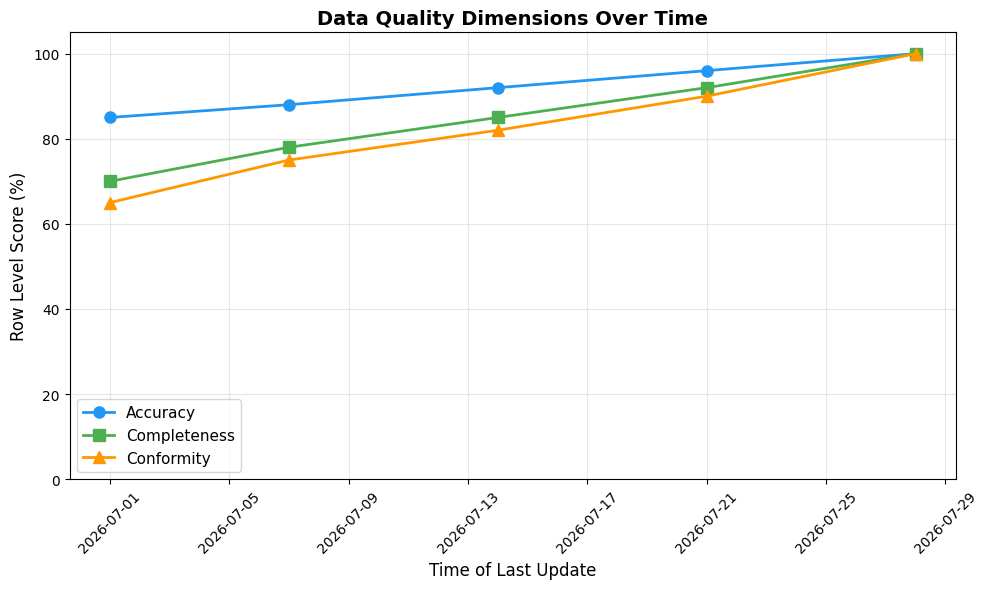

In [28]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


# Mock historical data (row-level percentages)
quality_history = [
    {'timestamp': '2026-07-01T00:00:00+08:00', 'accuracy': 85.00, 'completeness': 70.00, 'conformity': 65.00},
    {'timestamp': '2026-07-07T00:00:00+08:00', 'accuracy': 88.00, 'completeness': 78.00, 'conformity': 75.00},
    {'timestamp': '2026-07-14T00:00:00+08:00', 'accuracy': 92.00, 'completeness': 85.00, 'conformity': 82.00},
    {'timestamp': '2026-07-21T00:00:00+08:00', 'accuracy': 96.00, 'completeness': 92.00, 'conformity': 90.00},
]

# Add today's actual result from metrics
current_scores = {
    'timestamp': '2026-07-28T00:00:00+08:00',
    'accuracy': metrics['accuracy']['row_level'],
    'completeness': metrics['completeness']['row_level'],
    'conformity': metrics['conformity']['row_level'],
}
quality_history.append(current_scores)

def plot_quality_trend(quality_history):
    timestamps = [datetime.fromisoformat(entry['timestamp']) for entry in quality_history]
    accuracy = [entry['accuracy'] for entry in quality_history]
    completeness = [entry['completeness'] for entry in quality_history]
    conformity = [entry['conformity'] for entry in quality_history]

    plt.figure(figsize=(10, 6))
    plt.plot(timestamps, accuracy, 'o-', label='Accuracy', color='#2196F3', linewidth=2, markersize=8)
    plt.plot(timestamps, completeness, 's-', label='Completeness', color='#4CAF50', linewidth=2, markersize=8)
    plt.plot(timestamps, conformity, '^-', label='Conformity', color='#FF9800', linewidth=2, markersize=8)

    plt.xlabel('Time of Last Update', fontsize=12)
    plt.ylabel('Row Level Score (%)', fontsize=12)
    plt.title('Data Quality Dimensions Over Time', fontsize=14, fontweight='bold')
    plt.ylim(0, 105)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_quality_trend(quality_history)

#### ***Timeliness - Processing Duration***


The time taken to process the dataset, measured from when the first constituent dataset is received by the DPA, until processing is completed and the final dataset is ready.

Reference: [DPS v1.0](https://sgtechstack.atlassian.net/wiki/spaces/DATAPROVSD/pages/392336115/Timeliness)




In [13]:
# Mock timeliness data - processing duration in hours
timeliness_history = [
    {'timestamp': '2026-07-01T00:00:00+08:00', 'processing_duration_hours': 12.5},
    {'timestamp': '2026-07-07T00:00:00+08:00', 'processing_duration_hours': 8.4},
    {'timestamp': '2026-07-14T00:00:00+08:00', 'processing_duration_hours': 8.0},
    {'timestamp': '2026-07-21T00:00:00+08:00', 'processing_duration_hours': 5.5},
    {'timestamp': '2026-07-27T00:00:00+08:00', 'processing_duration_hours': 5.4},
]

def plot_timeliness_trend(timeliness_history):
    timestamps = [datetime.fromisoformat(entry['timestamp']) for entry in timeliness_history]
    durations = [entry['processing_duration_hours'] for entry in timeliness_history]

    plt.figure(figsize=(10, 6))
    plt.plot(timestamps, durations, 'D-', label='Processing Duration', color='#9C27B0', linewidth=2, markersize=8)

    plt.xlabel('Time of Last Update', fontsize=12)
    plt.ylabel('Timeliness - Processing Duration (hours)', fontsize=12)
    plt.title('Data Timeliness Over Time', fontsize=14, fontweight='bold')
    plt.ylim(0, max(durations) + 2)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


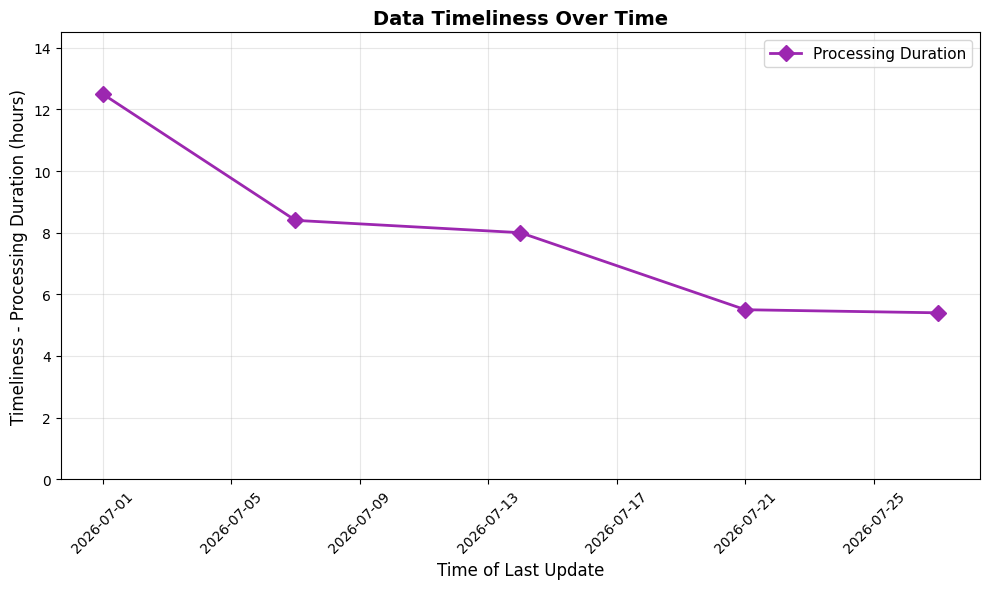

In [14]:
plot_timeliness_trend(timeliness_history)


#### **Formatting for DPS data quality metrics submission**

In [30]:
import json
dq_submission = {
    "agency_code": "AGENCY_A",
    "metrics": [
        {
            "data": {
                "unit": "count",
                "value": metrics['accuracy']['failed_records']
            },
            "name": "ACCURACY_REJECTED_ROWS"
        },
        {
            "data": {
                "unit": "%",
                "value": round(metrics['accuracy']['row_level'], 4)
            },
            "name": "POST_VALIDATION_ACCURACY_RATE"
        },
        {
            "data": {
                "unit": "count",
                "value": metrics['completeness']['failed_records']
            },
            "name": "COMPLETENESS_REJECTED_ROWS"
        },
        {
            "data": {
                "unit": "%",
                "value": round(metrics['completeness']['row_level'], 4)
            },
            "name": "POST_VALIDATION_COMPLETENESS_RATE"
        },
        {
            "data": {
                "unit": "ISO 8601",
                "value": "2026-07-28T00:00:00+08:00"
            },
            "name": "TIMELINESS_TIME_OF_LAST_UPDATE"
        },
        {
            "data": {
                "unit": "seconds",
                "value": 19440
            },
            "name": "TIMELINESS_PROCESSING_DURATION"
        },
    ],
    "reporter_email": "reporter@agencya.gov.sg",
    "reporting_date": "2026-07-28",
    "subscription_id": "49986cfe-d618-5c25-9cb0-71161f5b7652",
    "total_count": metrics['accuracy']['total_rows']
}


In [31]:
print(json.dumps(dq_submission, indent=2))

{
  "agency_code": "AGENCY_A",
  "metrics": [
    {
      "data": {
        "unit": "count",
        "value": 1
      },
      "name": "ACCURACY_REJECTED_ROWS"
    },
    {
      "data": {
        "unit": "%",
        "value": 99.9995
      },
      "name": "POST_VALIDATION_ACCURACY_RATE"
    },
    {
      "data": {
        "unit": "count",
        "value": 4
      },
      "name": "COMPLETENESS_REJECTED_ROWS"
    },
    {
      "data": {
        "unit": "%",
        "value": 99.998
      },
      "name": "POST_VALIDATION_COMPLETENESS_RATE"
    },
    {
      "data": {
        "unit": "ISO 8601",
        "value": "2026-07-28T00:00:00+08:00"
      },
      "name": "TIMELINESS_TIME_OF_LAST_UPDATE"
    },
    {
      "data": {
        "unit": "seconds",
        "value": 19440
      },
      "name": "TIMELINESS_PROCESSING_DURATION"
    }
  ],
  "reporter_email": "reporter@agencya.gov.sg",
  "reporting_date": "2026-07-28",
  "subscription_id": "49986cfe-d618-5c25-9cb0-71161f5b7652",
  "tot

## 🔍 **Section 3: Create your own data contract using your own golden dataset and validate against your own data**

Now that we have seen how to generate a data contract via **vowl-canvas** and validate data via **vowl-lens**, it is your turn to try it out! :D

1) You will need to first create your own data contract ***data_contract.yaml*** using your own golden dataset.
2) Validate your **dataset.csv** with **data_contract.yaml** via either **vowl-lens** or **vowl library**

The following steps are for validating data using **vowl library** instead of using **vowl-lens**:


**Step 1: You can upload your *dataset.csv* and *data_contract.yaml* into the *CRISPrWorkshop* folder.**

COMET users will need a workaround since the upload function is restricted.   


- SEED users: Refer to Step 1.1

- COMET users: Refer to Step 1.2

**Step 1.1: SEED users**
- From left sidebar, open files icon

- Upload your ***dataset.csv*** and ***data_contract.yaml*** into ***CRISPrWorkshop*** folder
- Ensure that the files are in correct folder
- Go to Step 2


In [17]:
!ls "/content/CRISPrWorkshop/"

CRISPr_notebook.ipynb	       hdb_resale_golden.csv	   README.md
hdb_resale_data_contract.yaml  hdb_resale_with_errors.csv


**Step 1.2: COMET users**
- COMET users need a workaround to get your dataset file into google colab due to limitation of upload function. However, you can still upload csv and yaml files in vowl-lens.
- Use any text editor like vscode to copy & paste the csv file and yaml file in the empty space below and write into the ***CRISPrWorkshop*** folder

  OR

- Go to vowl-ui and copy & paste the csv file and yaml file into the empty space below and write into ***CRISPrWorkshop*** folder

### **WORKAROUND FOR COMET USERS TO WRITE CSV INTO CRISPrWorkshop folder**


In [18]:
#CHANGE YOUR DATA SET AND DATA CONTRACT FILE NAMES HERE

dataset_name = 'dataset.csv'
datacontract_name = 'data_contract.yaml'

In [19]:
csv_data = """

<PASTE COPIED CSV OVER HERE>

"""

df = pd.read_csv(StringIO(csv_data))

file_path = f"/content/CRISPrWorkshop/{dataset_name}"
df.to_csv(file_path, index=False)

print(f"Saved to {file_path}")

Saved to /content/CRISPrWorkshop/dataset.csv


### **WORKAROUND FOR COMET USERS TO WRITE DATA CONTRACT YAML INTO CRISPrWorkshop folder**

In [20]:
yaml_content = r"""

<PASTE COPIED YAML OVER HERE>

"""

file_path = f"/content/CRISPrWorkshop/{datacontract_name}"

with open(file_path, "w") as f:
    f.write(yaml_content.strip())

print(f"Saved to {file_path}")

Saved to /content/CRISPrWorkshop/data_contract.yaml


In [21]:
!ls "/content/CRISPrWorkshop/"

CRISPr_notebook.ipynb  hdb_resale_data_contract.yaml  README.md
data_contract.yaml     hdb_resale_golden.csv
dataset.csv	       hdb_resale_with_errors.csv


### **Step 2: Validating your own data with vowl library**

In [ ]:
#Ensure that the file path is correct
df1 = pd.read_csv(f"/content/CRISPrWorkshop/{dataset_name}")
df1

In [ ]:
result1 = validate_data(f"/content/CRISPrWorkshop/{datacontract_name}", df=df1)

In [ ]:
result1.display_full_report()